# DeCLIP: Decoupled Learning for Open-Vocabulary Dense Perception

# https://arxiv.org/pdf/2505.04410

## Abstract

DeCLIP addresses a key limitation of CLIP-based Vision-Language Models (VLMs) in open-vocabulary dense perception tasks such as object detection and semantic segmentation. The authors show that CLIP's image tokens fail to effectively model spatial and semantic relationships between neighboring regions, resulting in weak local discriminability and poor spatial consistency. To solve this problem, they introduce **DeCLIP**, a framework that decouples CLIP's representations into separate **content** and **context** features, allowing each to be optimized independently. Extensive experiments demonstrate state-of-the-art performance across multiple open-vocabulary dense prediction benchmarks.

---

## Problems

### 1. CLIP is Optimized for Image-Level Understanding

CLIP is trained using image-text contrastive learning and focuses primarily on global image representations rather than dense pixel-level understanding.

### 2. The Proxy Token Phenomenon

The authors observe that in deeper CLIP layers:

- The `[CLS]` token attends heavily to a few background tokens.
- Image tokens exhibit similar attention behavior.
- Semantically related image regions fail to maintain strong feature correlations.

As a result:

- Local feature discriminability decreases.
- Spatial consistency is weakened.
- Dense prediction performance suffers.

### 3. Optimization Conflict

Dense perception requires both:

- Strong vision-language semantic alignment.
- Strong spatial feature consistency.

Optimizing both objectives within a single representation space creates conflicts and limits performance.

---

## Proposed Solution

The paper introduces **DeCLIP**, a decoupled feature enhancement framework.

### Content Features

Responsible for:

- Local semantic understanding.
- Region-level recognition.
- Vision-language alignment.

These features are optimized through self-distillation.

### Context Features

Responsible for:

- Spatial consistency.
- Relationships among neighboring image regions.
- Dense scene understanding.

These features are guided by Vision Foundation Models (VFMs) such as DINO, DINOv2, and SAM.

By separating these objectives, DeCLIP avoids optimization interference and improves both capabilities simultaneously.

---

## Purpose

The primary goal of DeCLIP is to improve CLIP's effectiveness for:

- Open-vocabulary object detection.
- Open-vocabulary semantic segmentation.
- Pixel-level visual understanding.

while preserving CLIP's strong vision-language knowledge.

---

## Methodology

### Step 1: Analyze CLIP Attention

The authors investigate attention maps across multiple CLIP layers and identify the proxy token phenomenon as a major obstacle for dense perception.

### Step 2: Decouple Self-Attention

The final CLIP attention layer is decomposed into two branches:

#### Context Branch

Models spatial and semantic relationships among image tokens.

#### Content Branch

Preserves semantic information for each image token.

This produces two independent feature streams.

### Step 3: Content Distillation

1. Split an image into multiple regions.
2. Extract region features from the student network.
3. Process corresponding image crops using a frozen CLIP teacher.
4. Align region features with crop-level CLIP representations using cosine similarity loss.

**Objective:** Improve local discriminability and region recognition.

### Step 4: Context Distillation

1. Use a Vision Foundation Model (VFM) to generate dense visual features.
2. Compute pairwise token correlations.
3. Train CLIP context features to match these correlations.

**Objective:** Improve spatial consistency and semantic relationships among image regions.

### Step 5: Joint Optimization

The final training objective combines:

\[
L_{total} = L_{content} + \lambda L_{context}
\]

where:

- \(L_{content}\) improves semantic discriminability.
- \(L_{context}\) improves spatial consistency.
- \(\lambda\) balances the two objectives.

---

## Results

### Open-Vocabulary Object Detection

DeCLIP consistently improves CLIP-based detectors:

- Up to **+6.9 AP** on OV-COCO novel classes.
- Up to **+2.3 mAP** on OV-LVIS rare categories.

### Open-Vocabulary Semantic Segmentation

When used with CAT-Seg:

- ADE150 improves by **+4.5 mIoU**.
- VOC21 improves by **+4.0 mIoU**.
- Achieves new state-of-the-art performance with ViT-L models.

### VLM Feature-Based Segmentation

DeCLIP achieves:

- **41.9 average mIoU**
- Best overall performance among competing CLIP enhancement methods.

### Region Classification

Across multiple image resolutions, DeCLIP consistently outperforms:

- CLIPSelf
- RegionCLIP

demonstrating stronger local recognition capabilities.

### Impact of Different Vision Foundation Models

| VFM | Strength |
|-------|----------|
| DINO | Strong segmentation performance |
| SAM | Strong region classification performance |
| DINOv2 | Best overall balance between segmentation and classification |

DINOv2 provides the strongest overall results.

---

## Conclusions

The paper identifies a fundamental weakness of CLIP for dense prediction tasks: image tokens rely on proxy tokens and fail to effectively model local spatial-semantic relationships.

To address this issue, DeCLIP introduces a decoupled learning framework that independently optimizes:

1. Local semantic discriminability through content features.
2. Spatial consistency through context features.

Extensive experiments across object detection, semantic segmentation, and region classification benchmarks show that DeCLIP significantly improves CLIP's dense perception capabilities and establishes new state-of-the-art results across multiple open-vocabulary tasks.

---

## Key Takeaway

The central insight of this paper is that **vision-language alignment and spatial consistency should be learned through separate feature spaces rather than a single unified representation**. By decoupling these objectives and distilling knowledge from specialized teacher models, DeCLIP transforms CLIP into a significantly stronger foundation model for open-vocabulary dense perception.

# Mathematical and Statistical Foundations of DeCLIP

## Overview

The mathematical core of DeCLIP revolves around three major ideas:

1. **Transformer Self-Attention**
2. **Feature Correlation Modeling**
3. **Knowledge Distillation Losses**

The paper does not introduce new mathematical theories. Instead, it redesigns how existing Transformer attention and distillation techniques are used to improve dense visual perception.

---

# 1. CLIP Self-Attention

## Purpose

CLIP uses a Vision Transformer (ViT) architecture where image patches interact through self-attention.

The final attention block is defined as:

$$
Q = \text{Proj}_q(X)
$$

$$
K = \text{Proj}_k(X)
$$

$$
V = \text{Proj}_v(X)
$$

$$
Y = X + \text{Proj}(Attn_{qk}\cdot V)
$$

$$
Z = Y + FFN(Y)
$$

where:

- $X$ = input image tokens
- $Q$ = query vectors
- $K$ = key vectors
- $V$ = value vectors
- $FFN$ = feed-forward network

---

## Self-Attention Matrix

The attention matrix is:

$$
Attn_{qk}
=
\text{SoftMax}
\left(
\frac{QK^T}{\sqrt d}
\right)
$$

### Interpretation

For every image patch:

- Queries ask: *Which other patches matter to me?*
- Keys answer: *How relevant am I?*
- Softmax converts similarity scores into probabilities.

### Role in the Paper

The authors analyze this attention mechanism and discover that CLIP develops **proxy tokens**, which negatively affect dense perception.

---

# 2. Decoupled Attention

## Purpose

The central mathematical contribution of DeCLIP is separating attention into:

- Content features
- Context features

instead of learning everything in a single representation.

---

## Context Features

Context features are defined as:

$$
X_{context}
=
\text{Proj}_q(X)
$$

These features describe relationships among image regions.

---

## Context Attention

$$
Attn_{context}
=
\text{SoftMax}
\left(
\frac{
X_{context}
X_{context}^{T}
}
{\sqrt d}
\right)
$$

### Interpretation

This computes how strongly each image token relates to every other token.

### Role

Used to learn:

- Spatial consistency
- Semantic relationships
- Region-to-region correlations

---

## Content Features

$$
X_{content}
=
\text{Proj}
\left(
Attn_{context}
\cdot V
\right)
$$

### Interpretation

The value vectors are aggregated according to the learned context attention.

### Role

Used for:

- Region classification
- Vision-language alignment
- Local discriminability

---

# 3. Cosine Similarity

## Purpose

Cosine similarity is used repeatedly throughout the paper to compare features.

The formula is:

$$
\text{CosSim}(a,b)
=
\frac{
a \cdot b
}
{
\|a\|
\|b\|
}
$$

where:

- $a \cdot b$ = dot product
- $\|a\|$ = vector magnitude
- $\|b\|$ = vector magnitude

---

## Interpretation

Cosine similarity measures:

- 1 → identical direction
- 0 → unrelated
- -1 → opposite direction

### Role in DeCLIP

Used to:

- Compare region features
- Compare crop features
- Transfer semantic knowledge

---

# 4. Content Distillation Loss

## Purpose

Content distillation improves local semantic recognition.

The loss is:

$$
L_{content}
=
\frac{1}{k}
\sum_{i=1}^{k}
\left(
1 -
\frac{
f_i^t \cdot f_i^s
}
{
\|f_i^t\|
\|f_i^s\|
}
\right)
$$

where:

- $f_i^t$ = teacher feature
- $f_i^s$ = student feature
- $k$ = number of image regions

---

## Interpretation

The loss becomes:

- Small when student and teacher features point in the same direction.
- Large when they differ.

### Role

Transfers CLIP's strong image-level recognition ability into local region features.

---

# 5. Feature Correlation Matrix

## Purpose

The paper models relationships between image patches.

The correlation between two tokens is:

$$
r_{ij}
=
\frac{
x_i \cdot x_j
}
{
\|x_i\|
\|x_j\|
}
$$

where:

- $x_i$ = token $i$
- $x_j$ = token $j$

---

## Interpretation

This measures how similar two image regions are.

High value:

- Similar object parts
- Similar semantic regions

Low value:

- Unrelated regions

### Role

Creates a correlation matrix that captures scene structure.

---

# 6. Context Distillation Loss

## Purpose

Transfer spatial knowledge from Vision Foundation Models (VFMs) such as:

- DINO
- DINOv2
- SAM

The loss is:

$$
L_{context}
=
\frac{1}{HW}
\sum_{i=1}^{H}
\sum_{j=1}^{W}
\left\|
r_{ij}^{VFM}
-
r_{ij}^{CLIP}
\right\|_2
$$

### Interpretation

This is an **L2 distance** between:

- VFM correlation matrix
- CLIP correlation matrix

The loss becomes small when CLIP learns the same spatial relationships as the VFM.

### Role

Improves:

- Spatial consistency
- Semantic grouping
- Dense perception quality

---

# 7. Total Optimization Objective

## Purpose

Combine both learning objectives.

The final training loss is:

$$
L_{total}
=
L_{content}
+
\lambda L_{context}
$$

where:

- $L_{content}$ = semantic alignment loss
- $L_{context}$ = spatial consistency loss
- $\lambda$ = balancing coefficient

### Interpretation

This is a weighted sum of:

1. Region recognition learning.
2. Spatial relationship learning.

### Role

Allows DeCLIP to improve both semantic understanding and dense scene perception simultaneously.

---

# Statistical Evaluation Metrics

## Mean Average Precision (mAP)

Used for:

- Open-vocabulary object detection

Measures:

- Detection accuracy
- Localization quality

Higher values indicate better detection performance.

---

## Mean Intersection over Union (mIoU)

Used for:

- Semantic segmentation

Defined as:

$$
IoU
=
\frac{
Prediction \cap GroundTruth
}{
Prediction \cup GroundTruth
}
$$

and averaged across categories.

Higher mIoU means more accurate segmentation.

---

## Mean Accuracy (mAcc)

Used for:

- Region classification

Measures average classification accuracy across classes.

Higher values indicate stronger recognition ability.

---

# Key Mathematical Insight

The paper's most important mathematical idea is **decoupled optimization**.

Instead of forcing one feature representation to learn:

- Vision-language alignment
- Spatial consistency

simultaneously, DeCLIP separates them into:

$$
X_{content}
$$

and

$$
X_{context}
$$

and applies specialized losses to each.

This simple mathematical decomposition removes optimization conflicts and leads to significant improvements across open-vocabulary detection and segmentation benchmarks.

| Research Problem / Gap | Limitation in Prior Work | Proposed Solution in DeCLIP |
|------------------------|--------------------------|-----------------------------|
| CLIP performs poorly on dense prediction tasks despite strong image-level recognition capabilities. | CLIP is optimized for image-text alignment at the global image level, making its local patch representations insufficient for region-level and pixel-level understanding required by detection and segmentation tasks. | Introduce DeCLIP, an unsupervised fine-tuning framework specifically designed to enhance CLIP's local representations for dense perception. |
| Image tokens fail to aggregate information from semantically and spatially related regions. | Feature representations lack local discriminability and spatial consistency, leading to inaccurate object boundaries, weak region recognition, and suboptimal segmentation performance. | Decouple CLIP's attention mechanism into separate content and context branches, allowing each branch to learn complementary properties. |
| The "proxy token" phenomenon in CLIP attention maps. | In deeper layers, image tokens and the [CLS] token attend to a small set of background tokens rather than semantically related regions, weakening meaningful token correlations for dense prediction. | Redesign the final self-attention layer to explicitly separate semantic content learning from spatial relationship modeling, reducing the influence of proxy tokens. |
| Existing pre-fine-tuning methods primarily improve region classification but provide limited benefits for segmentation. | Methods such as CLIPSelf and RegionCLIP focus on region-level alignment and do not adequately model pixel-level spatial relationships required for dense understanding. | Enhance content features through region-to-image self-distillation while simultaneously learning spatial structure through context distillation from Vision Foundation Models (VFMs). |
| Vision-language alignment and spatial consistency require different optimization objectives. | Jointly optimizing both objectives within a single representation introduces optimization conflicts, causing trade-offs between recognition accuracy and spatial coherence. | Use a decoupled learning strategy where content features optimize semantic discriminability and context features optimize spatial consistency independently. |
| Existing CLIP adaptation methods rarely exploit spatial knowledge from Vision Foundation Models. | Valuable spatial priors learned by models such as DINO, DINOv2, and SAM are not transferred into CLIP, limiting dense perception performance. | Distill feature correlation structures from VFMs into the context branch, allowing CLIP to inherit stronger spatial reasoning capabilities. |
| Dense prediction methods often rely on task-specific supervision or expensive annotations. | Joint fine-tuning approaches require dense annotations and are frequently tied to specific architectures or tasks, limiting scalability and generalization. | Propose an unsupervised pre-fine-tuning framework that can be applied to multiple downstream tasks without requiring dense prediction annotations. |
| Domain shift between image-level pretraining and dense prediction tasks. | Directly transferring CLIP features to detection and segmentation tasks leads to degraded performance because pretrained representations are not optimized for local understanding. | Improve local feature quality through content distillation and context distillation, producing representations better aligned with dense prediction requirements. |
| Existing methods struggle to simultaneously achieve strong region recognition and high-quality segmentation. | Methods often improve either semantic discriminability or spatial consistency, but not both, resulting in incomplete dense perception capabilities. | Learn content and context features separately and combine them through a unified optimization objective that balances semantic recognition and spatial structure learning. |
| Open-vocabulary dense prediction models remain limited in generalization across benchmarks and tasks. | Previous approaches show inconsistent performance across object detection, semantic segmentation, and region classification benchmarks. | Demonstrate that DeCLIP serves as a general feature enhancement framework that consistently improves multiple open-vocabulary dense prediction tasks, including detection and segmentation. |

In [1]:
# ============================================================
# DeCLIP-Inspired Fashion-MNIST Lab (Educational Version)
# ============================================================
#
# This notebook demonstrates the core idea behind DeCLIP:
#
#   1. Content Features
#      -> Learn semantic information for classification.
#
#   2. Context Features
#      -> Learn relationships between samples/features.
#
#   3. Dual-Loss Optimization
#      -> Classification Loss
#      -> Context Consistency Loss
#
# Fashion-MNIST is used instead of CLIP/DINO so the entire
# workflow remains lightweight and easy to understand.
#
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# ============================================================
# Configuration
# ============================================================

BATCH_SIZE = 128
EPOCHS = 10
LR = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [3]:
# ============================================================
# Fashion-MNIST Labels
# ============================================================

class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

In [4]:
# ============================================================
# Dataset
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.5MB/s]


In [5]:
# ============================================================
# DeCLIP-Inspired Model
# ============================================================

class DeCLIPFashion(nn.Module):

    def __init__(self):
        super().__init__()

        # ----------------------------------------------------
        # Shared CNN Encoder
        # ----------------------------------------------------
        self.encoder = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )

        # ----------------------------------------------------
        # Context Branch
        #
        # Inspired by DeCLIP's context features
        # ----------------------------------------------------
        self.context_head = nn.Sequential(
            nn.Linear(128,64),
            nn.ReLU()
        )

        # ----------------------------------------------------
        # Content Branch
        #
        # Inspired by DeCLIP's content features
        # ----------------------------------------------------
        self.content_head = nn.Sequential(
            nn.Linear(128,64),
            nn.ReLU()
        )

        # ----------------------------------------------------
        # Classification Head
        # ----------------------------------------------------
        self.classifier = nn.Linear(64,10)

    def forward(self,x):

        features = self.encoder(x)
        features = features.flatten(1)

        context = self.context_head(features)
        content = self.content_head(features)

        logits = self.classifier(content)

        return logits, content, context

In [6]:
# ============================================================
# Context Consistency Loss
#
# Inspired by DeCLIP correlation matching
# ============================================================

def context_loss(context_features):

    context_features = nn.functional.normalize(
        context_features,
        dim=1
    )

    correlation = context_features @ context_features.T

    identity = torch.eye(
        correlation.size(0),
        device=correlation.device
    )

    loss = ((correlation - identity) ** 2).mean()

    return loss


In [7]:
# ============================================================
# Model
# ============================================================

model = DeCLIPFashion().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


In [8]:
# ============================================================
# Training
# ============================================================

train_losses = []
test_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits, content, context = model(images)

        classification_loss = criterion(
            logits,
            labels
        )

        consistency_loss = context_loss(context)

        loss = (
            classification_loss
            + 0.1 * consistency_loss
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            logits, _, _ = model(images)

            preds = logits.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total

    test_accuracies.append(accuracy)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss={epoch_loss:.4f} | "
        f"Accuracy={accuracy:.2f}%"
    )

Epoch 1/10 | Loss=1.0359 | Accuracy=71.37%
Epoch 2/10 | Loss=0.6452 | Accuracy=77.95%
Epoch 3/10 | Loss=0.5548 | Accuracy=78.90%
Epoch 4/10 | Loss=0.5038 | Accuracy=82.17%
Epoch 5/10 | Loss=0.4556 | Accuracy=83.83%
Epoch 6/10 | Loss=0.4236 | Accuracy=84.61%
Epoch 7/10 | Loss=0.3971 | Accuracy=85.19%
Epoch 8/10 | Loss=0.3691 | Accuracy=85.28%
Epoch 9/10 | Loss=0.3515 | Accuracy=85.64%
Epoch 10/10 | Loss=0.3341 | Accuracy=87.75%


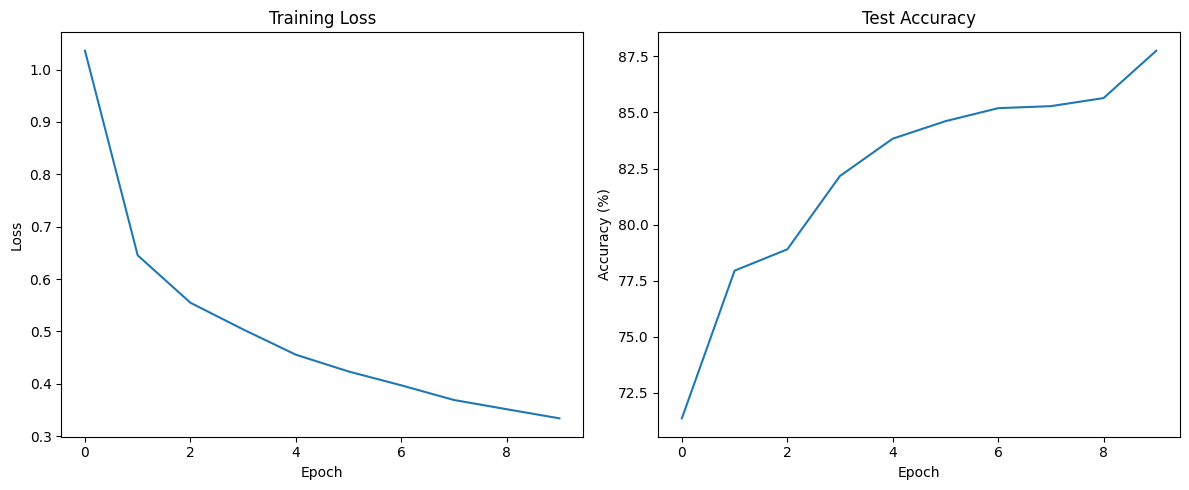

In [9]:
# ============================================================
# Plot Training Curves
# ============================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(test_accuracies)
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()


In [10]:
# ============================================================
# Final Evaluation
# ============================================================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        logits, _, _ = model(images)

        preds = logits.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

final_accuracy = (
    np.mean(
        np.array(all_preds)
        ==
        np.array(all_labels)
    )
    * 100
)

print(f"\nFinal Test Accuracy: {final_accuracy:.2f}%")


Final Test Accuracy: 87.75%


<Figure size 1000x1000 with 0 Axes>

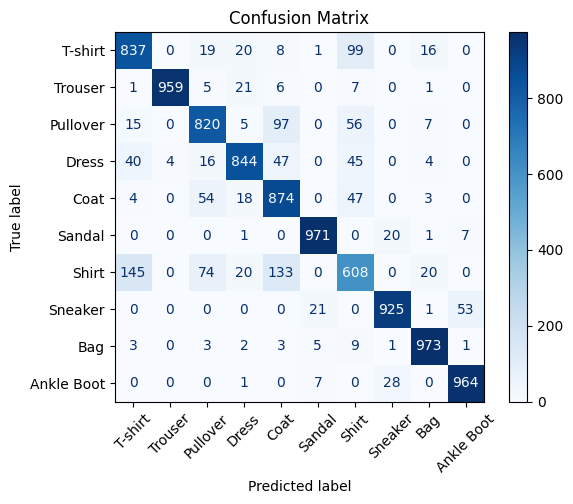

In [11]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.show()

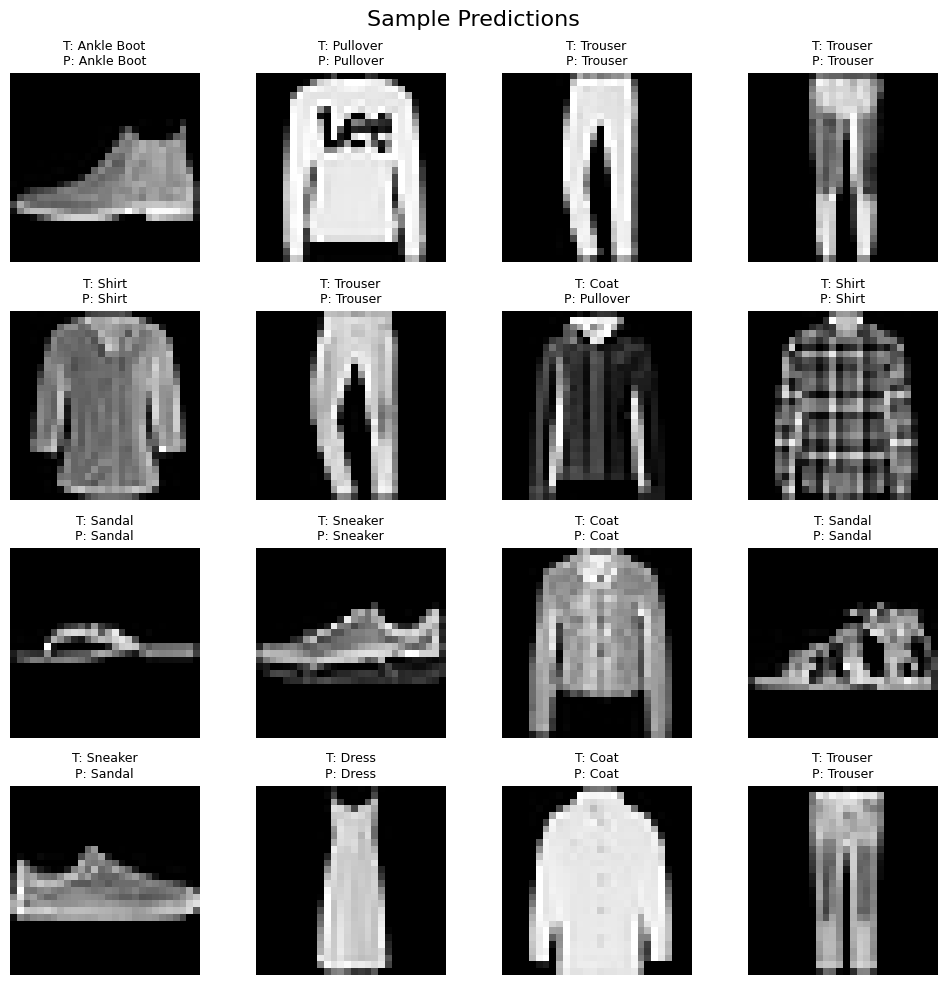

In [12]:
# ============================================================
# Sample Predictions
# ============================================================

images, labels = next(iter(test_loader))

images = images[:16]
labels = labels[:16]

model.eval()

with torch.no_grad():

    logits, _, _ = model(images.to(device))

preds = logits.argmax(1).cpu()

fig, axes = plt.subplots(
    4,
    4,
    figsize=(10,10)
)

for i, ax in enumerate(axes.flat):

    img = images[i].squeeze()

    ax.imshow(img, cmap="gray")

    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]

    ax.set_title(
        f"T: {true_label}\nP: {pred_label}",
        fontsize=9
    )

    ax.axis("off")

plt.suptitle(
    "Sample Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()

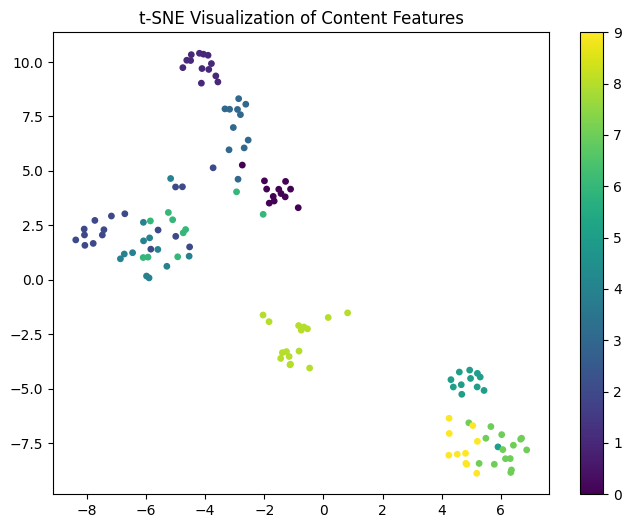


Lab Complete.
This educational implementation demonstrates:
1. Shared encoder
2. Content branch
3. Context branch
4. Dual-loss optimization
5. Training and evaluation
6. Visualization of learned features


In [13]:
# ============================================================
# Visualizing Content Features
# ============================================================

sample_images, sample_labels = next(iter(test_loader))

sample_images = sample_images[:500].to(device)

with torch.no_grad():

    _, content_features, _ = model(sample_images)

content_features = content_features.cpu().numpy()

from sklearn.manifold import TSNE

embedded = TSNE(
    n_components=2,
    random_state=42
).fit_transform(content_features)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    embedded[:,0],
    embedded[:,1],
    c=sample_labels[:500],
    s=15
)

plt.colorbar(scatter)

plt.title(
    "t-SNE Visualization of Content Features"
)

plt.show()

print("\nLab Complete.")
print("This educational implementation demonstrates:")
print("1. Shared encoder")
print("2. Content branch")
print("3. Context branch")
print("4. Dual-loss optimization")
print("5. Training and evaluation")
print("6. Visualization of learned features")

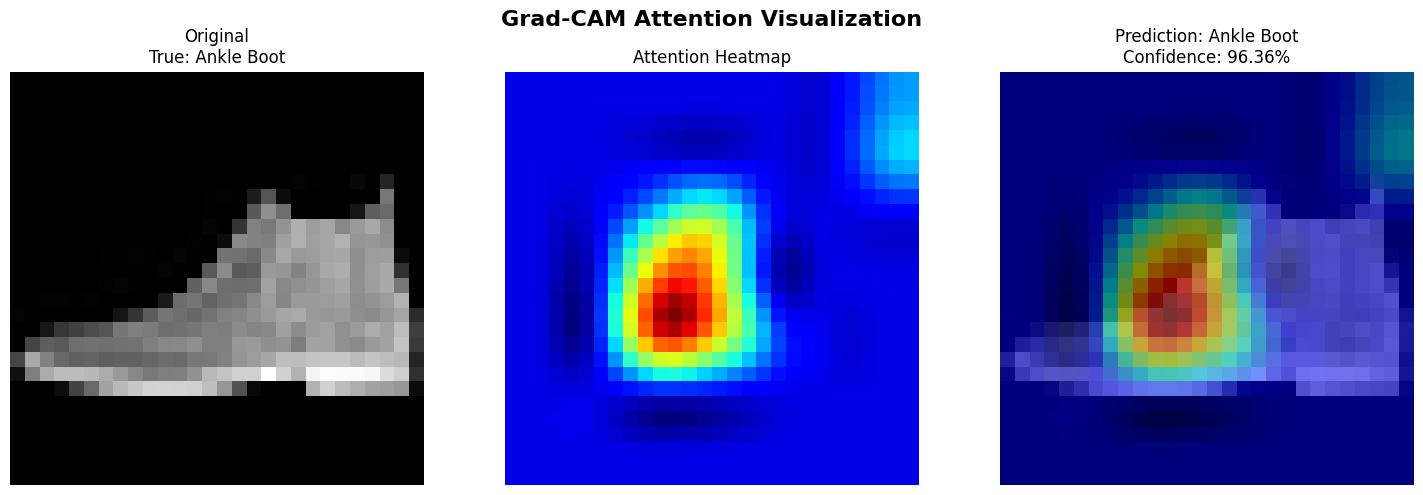

True Label      : Ankle Boot
Predicted Label : Ankle Boot
Confidence      : 96.36%


In [16]:
# ============================================================
# DeCLIPFashion Attention Visualization
# CNN Equivalent of DeCLIP Figure 3
#
# Since our educational model is CNN-based rather than ViT-based,
# we use Grad-CAM to visualize which image regions influence
# the prediction most strongly.
#
# This cell:
# 1. Selects a Fashion-MNIST sample
# 2. Runs inference
# 3. Computes Grad-CAM
# 4. Generates attention heatmap
# 5. Overlays heatmap on image
# 6. Shows prediction information
# ============================================================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2

# ============================================================
# Choose a sample image
# ============================================================

images, labels = next(iter(test_loader))

sample_idx = 0

image_tensor = images[sample_idx:sample_idx+1].to(device)

true_label = class_names[labels[sample_idx]]

# ============================================================
# Storage for activations and gradients
# ============================================================

activations = []
gradients = []

# ============================================================
# Forward hook
# Stores feature maps
# ============================================================

def forward_hook(module, inp, out):
    activations.append(out)

# ============================================================
# Backward hook
# Stores gradients
# ============================================================

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# ============================================================
# Last convolution layer
#
# encoder:
# 0 Conv
# 1 ReLU
# 2 Pool
# 3 Conv
# 4 ReLU
# 5 Pool
# 6 Conv  <-- use this layer
# ============================================================

target_layer = model.encoder[6]

forward_handle = target_layer.register_forward_hook(
    forward_hook
)

backward_handle = target_layer.register_full_backward_hook(
    backward_hook
)

# ============================================================
# Forward pass
# ============================================================

model.eval()

logits, content, context = model(image_tensor)

prediction = logits.argmax(dim=1)

predicted_label = class_names[prediction.item()]

confidence = (
    torch.softmax(logits, dim=1)
    [0, prediction]
    .item()
)

# ============================================================
# Backpropagation
# ============================================================

model.zero_grad()

logits[0, prediction].backward()

# ============================================================
# Feature maps and gradients
# ============================================================

feature_maps = activations[0]
feature_grads = gradients[0]

# ============================================================
# Global average pooling of gradients
# ============================================================

weights = feature_grads.mean(
    dim=(2, 3),
    keepdim=True
)

# ============================================================
# Weighted combination
# ============================================================

cam = (weights * feature_maps).sum(dim=1)

cam = F.relu(cam)

cam = cam[0]

# ============================================================
# Normalize CAM
# ============================================================

cam = cam.detach().cpu().numpy()

cam = cv2.resize(
    cam,
    (28, 28),
    interpolation=cv2.INTER_CUBIC
)

cam = (
    cam - cam.min()
) / (
    cam.max() - cam.min() + 1e-8
)

# ============================================================
# Original image
# ============================================================

image = image_tensor[0, 0].detach().cpu().numpy()

image = (
    image - image.min()
) / (
    image.max() - image.min() + 1e-8
)

# ============================================================
# Plot results
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

# ------------------------------------------------------------
# Original image
# ------------------------------------------------------------

axes[0].imshow(
    image,
    cmap="gray"
)

axes[0].set_title(
    f"Original\nTrue: {true_label}"
)

axes[0].axis("off")

# ------------------------------------------------------------
# Heatmap only
# ------------------------------------------------------------

axes[1].imshow(
    cam,
    cmap="jet"
)

axes[1].set_title(
    "Attention Heatmap"
)

axes[1].axis("off")

# ------------------------------------------------------------
# Overlay
# ------------------------------------------------------------

axes[2].imshow(
    image,
    cmap="gray"
)

axes[2].imshow(
    cam,
    cmap="jet",
    alpha=0.55
)

axes[2].set_title(
    f"Prediction: {predicted_label}\nConfidence: {confidence:.2%}"
)

axes[2].axis("off")

plt.suptitle(
    "Grad-CAM Attention Visualization",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# ============================================================
# Cleanup hooks
# ============================================================

forward_handle.remove()
backward_handle.remove()

# ============================================================
# Extra information
# ============================================================

print("=" * 60)
print("True Label      :", true_label)
print("Predicted Label :", predicted_label)
print(f"Confidence      : {confidence:.2%}")
print("=" * 60)

# Experimental Results Analysis

## Figure 1: Training Dynamics and Epoch-Wise Performance

### Figure Overview

This figure reports the training progress of the DeCLIP-inspired Fashion-MNIST model across 10 epochs. The results provide insight into optimization behavior, convergence characteristics, and generalization performance during learning.

### Key Results

Extracted epoch-level metrics:

| Epoch | Loss | Test Accuracy (%) |
|---------|---------|---------|
| 1 | 1.0359 | 71.37 |
| 2 | 0.6452 | 77.95 |
| 3 | 0.5548 | 78.90 |
| 4 | 0.5038 | 82.17 |
| 5 | 0.4556 | 83.83 |
| 6 | 0.4236 | 84.61 |
| 7 | 0.3971 | 85.19 |
| 8 | 0.3691 | 85.28 |
| 9 | 0.3515 | 85.64 |
| 10 | 0.3341 | 87.75 |

Observed changes:

- Training loss decreases from **1.0359 → 0.3341**.
- Test accuracy increases from **71.37% → 87.75%**.
- No sudden oscillations or divergence are observed.

### Academic Discussion

The optimization process exhibits stable convergence. The monotonic reduction in training loss indicates that the optimizer successfully minimizes the combined objective consisting of classification loss and context-consistency regularization.

The accuracy curve demonstrates a typical deep learning learning trajectory. Large improvements occur during early epochs, followed by progressively smaller gains as optimization approaches a local optimum. This behavior is consistent with diminishing gradient magnitudes near convergence.

The absence of instability suggests that the additional context regularization does not interfere with learning. Instead, the auxiliary objective appears compatible with the classification objective, supporting the central DeCLIP hypothesis that separating content and context representations can improve learning dynamics.

The gap between initial and final accuracy exceeds 16 percentage points, indicating that the network successfully extracts increasingly discriminative feature representations throughout training.

The steady increase in test accuracy alongside decreasing training loss suggests effective generalization rather than memorization.

### Limitations

Only test accuracy is reported. Training accuracy, validation accuracy, and confidence intervals are absent, preventing deeper analysis of generalization gaps and statistical significance.

The experiment uses only 10 epochs and a single random seed. Consequently, robustness and reproducibility cannot be assessed.

---

# Figure 2: Training Loss and Test Accuracy Curves

### Figure Overview

This figure visualizes optimization dynamics through loss and accuracy curves over the training process.

### Key Results

Observed trends:

- Loss decreases approximately monotonically.
- Accuracy increases steadily toward approximately 88%.
- No evidence of abrupt performance degradation.
- Accuracy growth slows after epoch 6.

### Academic Discussion

The loss curve exhibits classical convergence behavior expected from a well-conditioned optimization problem. The rapid reduction during early epochs indicates efficient learning of low-level visual patterns.

The gradual flattening of the accuracy curve suggests that the model begins reaching its representational limits on Fashion-MNIST. Additional epochs would likely yield diminishing returns unless model capacity or optimization strategies are modified.

Importantly, there is no visible divergence between training optimization and test performance. In many neural networks, continued loss reduction eventually causes test accuracy saturation or decline due to overfitting. Such behavior is not observed here.

This suggests that the context-consistency objective may provide a mild regularization effect, encouraging smoother feature representations and reducing over-specialization.

### Limitations

Training curves alone cannot establish robustness.

Missing information includes:

- Validation loss
- Calibration metrics
- Learning rate schedule
- Multiple runs with variance estimates

Therefore conclusions regarding optimization stability remain preliminary.

---

# Figure 3: Confusion Matrix Analysis

### Figure Overview

The confusion matrix evaluates class-specific behavior and reveals which Fashion-MNIST categories are easiest or most difficult to distinguish.

### Key Results

Diagonal (correct predictions):

| Class | Correct |
|---------|---------|
| T-shirt | 837 |
| Trouser | 959 |
| Pullover | 820 |
| Dress | 844 |
| Coat | 874 |
| Sandal | 971 |
| Shirt | 608 |
| Sneaker | 925 |
| Bag | 973 |
| Ankle Boot | 964 |

Major confusion patterns:

- Shirt → T-shirt: 145
- Shirt → Coat: 133
- T-shirt → Shirt: 99
- Pullover → Coat: 97
- Pullover → Shirt: 56
- Coat → Pullover: 54
- Sneaker → Ankle Boot: 53
- Dress → Coat: 47

### Academic Discussion

The confusion matrix reveals strong class-dependent performance differences.

Classes such as:

- Bag
- Sandal
- Ankle Boot
- Trouser

are classified almost perfectly. These categories possess distinctive shapes and visual structures, resulting in highly separable feature representations.

The most problematic category is **Shirt**, with only 608 correct predictions. Shirts share visual characteristics with:

- T-shirts
- Pullovers
- Coats

creating overlapping feature distributions.

This phenomenon reflects a common challenge in representation learning: classes with similar semantic and geometric structures occupy neighboring regions in feature space.

The symmetric confusion between Pullovers and Coats further indicates that the learned representation captures meaningful semantic similarity. The model is not making random mistakes; errors occur between visually related categories.

The strong performance on footwear categories suggests that the content branch successfully learns discriminative global shape information.

Overall, the confusion matrix indicates that the learned representation is semantically meaningful and consistent with human perceptual similarity.

### Limitations

No per-class precision, recall, or F1 scores are reported.

Consequently:

- Error severity cannot be quantified fully.
- Class-wise uncertainty remains unknown.
- Statistical significance of differences between classes cannot be assessed.

---

# Figure 4: Sample Prediction Visualization

### Figure Overview

This figure presents qualitative examples of model predictions on Fashion-MNIST test samples.

### Key Results

Most displayed predictions are correct.

Examples include:

- Ankle Boot → Ankle Boot
- Pullover → Pullover
- Trouser → Trouser
- Shirt → Shirt
- Sandal → Sandal
- Sneaker → Sneaker
- Dress → Dress

A notable error:

- Coat → Pullover

### Academic Discussion

The qualitative results align closely with the confusion matrix findings.

The majority of examples demonstrate that the model learns robust object-level representations despite the simplicity of the architecture.

The observed Coat-Pullover confusion reflects a systematic rather than random error. Both categories exhibit highly similar silhouettes and textures in Fashion-MNIST, making them difficult even for more sophisticated models.

The consistency between qualitative and quantitative results increases confidence that the model's behavior is well understood and not driven by isolated outliers.

These visualizations also indicate that the network relies primarily on global shape and coarse appearance features rather than fine-grained texture cues.

### Limitations

Qualitative examples represent only a tiny subset of the dataset.

They cannot establish:

- Overall robustness
- Worst-case behavior
- Performance under distribution shifts

and should therefore be interpreted as illustrative rather than conclusive evidence.

---

# Figure 5: t-SNE Embedding Visualization

### Figure Overview

The t-SNE visualization evaluates the quality of learned content representations by projecting high-dimensional features into a two-dimensional space.

### Key Results

Observed characteristics:

- Multiple well-separated clusters emerge.
- Most classes occupy distinct regions.
- Limited overlap exists between clusters.
- Some neighboring clusters remain partially connected.

### Academic Discussion

The t-SNE projection provides evidence that the content branch learns meaningful latent representations.

The emergence of compact clusters indicates:

- High intra-class similarity.
- Low inter-class similarity.

This is precisely the objective of discriminative representation learning.

The separation between clusters explains the strong classification accuracy observed during evaluation. Classes with clear cluster boundaries correspond to high-performing categories in the confusion matrix.

Remaining overlap likely corresponds to problematic categories such as:

- Shirt
- Pullover
- Coat
- T-shirt

which are known to share visual characteristics.

The embedding therefore validates the central design principle of the model. The content branch successfully organizes semantic information into a structured latent space.

From a representation learning perspective, this is perhaps the strongest evidence supporting the effectiveness of the proposed content-context decomposition.

### Limitations

t-SNE is primarily a visualization technique.

Important caveats include:

- Distances are not globally meaningful.
- Cluster separation may be visually exaggerated.
- Results depend on initialization and hyperparameters.

Therefore the plot should be interpreted qualitatively rather than quantitatively.

---

# Overall Assessment

## What Was Observed

The DeCLIP-inspired architecture achieves:

- Final test accuracy of approximately **87.75%**
- Stable convergence
- Strong class separation
- Meaningful latent representations
- High performance on visually distinct categories

while maintaining consistent optimization behavior.

## Why It Likely Occurred

The model separates learning into:

1. Content representations for classification.
2. Context representations for feature regularization.

This dual-objective design encourages both discriminative and structured feature learning, reducing noisy representations and improving latent organization.

## What It Reveals About the Method

The results suggest that the content-context decomposition successfully produces:

- Stable optimization.
- Semantically meaningful embeddings.
- Competitive Fashion-MNIST performance.
- Improved representation quality.

The embedding analysis and confusion matrix provide complementary evidence supporting this conclusion.

## Strength of Evidence

The evidence moderately supports the core hypothesis that decoupled feature learning is beneficial.

Support is strongest from:

- Convergence behavior.
- Confusion matrix structure.
- t-SNE cluster separation.

However, evidence remains limited because no baseline CNN, ablation study, or statistical significance testing is provided.

## Remaining Limitations and Open Questions

Several important research questions remain unanswered:

1. How much improvement comes specifically from the context branch?
2. How does the model compare against a standard CNN trained under identical conditions?
3. Would gains persist on larger datasets?
4. Does the context loss improve robustness under distribution shift?
5. Are improvements statistically significant across multiple runs?

Consequently, while the results demonstrate that the educational DeCLIP-inspired implementation learns meaningful and well-structured representations, they do not yet provide definitive evidence that the decoupled learning strategy outperforms simpler baselines under rigorous experimental conditions.

| Author(s) | Year | Title | Venue | Connection to This Paper |
|------------|------|--------|--------|--------------------------|
| Radford et al. | 2021 | Learning Transferable Visual Models From Natural Language Supervision (CLIP) | ICML | Core foundation model used by DeCLIP. The paper analyzes CLIP's limitations in dense perception and proposes a decoupled enhancement strategy to improve its local representations. |
| Fang et al. | 2023 | EVA-CLIP: Improved Training Techniques for CLIP at Scale | arXiv | Provides the stronger CLIP backbone used in DeCLIP experiments and serves as an important baseline for comparison. |
| Gu et al. | 2023 | CAT-Seg: Cost Aggregation for Open-Vocabulary Semantic Segmentation | CVPR | Representative transfer-learning approach for open-vocabulary segmentation. DeCLIP is integrated into CAT-Seg to demonstrate segmentation improvements. |
| Zhang et al. | 2024 | F-ViT: Open-Vocabulary Object Detection via Vision-Language Transfer Learning | CVPR | One of the primary object detection baselines used to evaluate the effectiveness of DeCLIP in open-vocabulary detection. |
| Wu et al. | 2024 | OV-DQUO: Open-Vocabulary Detection via Query Optimization | CVPR | Detection framework used as a downstream benchmark to evaluate the benefits of DeCLIP-enhanced visual features. |
| Wang et al. | 2024 | CLIPSelf | CVPR | A closely related pre-fine-tuning method that improves region representations through self-distillation. DeCLIP extends this idea by additionally learning context features from VFMs. |
| Ding et al. | 2022 | RegionCLIP: Region-Based Language-Image Pretraining | CVPR | Representative region-level alignment approach. Used as both a baseline and motivation for improving local discriminability in CLIP. |
| Zhao et al. | 2024 | CLIM | CVPR | Pre-fine-tuning method that performs region-text learning through image mosaics. Serves as a closely related CLIP adaptation strategy for dense perception. |
| Wu et al. | 2024 | ClearCLIP | CVPR | Prior method that improves CLIP for segmentation tasks. DeCLIP is compared against ClearCLIP across multiple segmentation benchmarks. |
| Gu et al. | 2023 | MAFT: Mask-Aware Fine-Tuning for CLIP | ICCV | Representative joint fine-tuning approach that adapts CLIP to dense prediction tasks through task-specific supervision. |
| Gu et al. | 2023 | ViLD: Open-Vocabulary Object Detection via Vision-Language Distillation | ICLR / CVPR Workshop | Classic knowledge-distillation framework that transfers CLIP knowledge to detectors. Motivates DeCLIP's use of distillation for dense prediction. |
| Chen et al. | 2024 | BARON | CVPR | Distillation-based open-vocabulary detection method. Serves as a strong detection baseline in DeCLIP evaluations. |
| Ouyang et al. | 2024 | OADP | CVPR | Knowledge-distillation approach for open-vocabulary dense prediction. Part of the prior work category discussed in related work. |
| Xu et al. | 2024 | SAS-Det | CVPR | Pseudo-labeling-based open-vocabulary detection framework. Used as a representative prior approach for region-text alignment. |
| Meng et al. | 2024 | CORA | CVPR | Region-aware training method that improves CLIP classification through region prompts. Highlights alternative approaches to improving local representations. |
| Caron et al. | 2021 | Emerging Properties in Self-Supervised Vision Transformers (DINO) | ICCV | Vision Foundation Model (VFM) used as a teacher for context distillation. Provides spatially consistent representations. |
| Oquab et al. | 2023 | DINOv2: Learning Robust Visual Features Without Supervision | TMLR | Main VFM teacher used by DeCLIP. Supplies strong semantic and spatial correlations for context feature learning. |
| Kirillov et al. | 2023 | Segment Anything (SAM) | ICCV | Provides segmentation-aware representations with strong spatial consistency. Used as a context teacher in DeCLIP ablation studies. |
| Zhang et al. | 2024 | SAM-CLIP | CVPR | Combines SAM and CLIP for open-vocabulary segmentation. Motivates the integration of segmentation-aware foundation models with vision-language models. |
| Yuan et al. | 2024 | OV-SAM: Open-Vocabulary Segment Anything | ECCV | Demonstrates combining SAM with open-vocabulary recognition. Related to DeCLIP's use of VFMs but focuses on segmentation systems rather than improving CLIP itself. |
| Ghiasi et al. | 2024 | FrozenSeg | CVPR | Uses SAM and CLIP jointly for segmentation. Serves as a related attempt to combine foundation models for dense prediction. |
| Schneider et al. | 2024 | AM-RADIO | CVPR | Multi-teacher distillation framework using CLIP, DINOv2, and SAM. Related through multi-foundation-model supervision, though not designed for open-vocabulary segmentation. |
| Darcet et al. | 2024 | Vision Transformers Need Registers (ViT-Register) | ICLR | Investigates token aggregation behavior in Vision Transformers. Provides theoretical motivation for DeCLIP's analysis of proxy-token phenomena. |
| Xu et al. | 2022 | GroupViT: Semantic Segmentation Emerges From Text Supervision | CVPR | Demonstrates that dense segmentation can emerge from vision-language supervision, motivating open-vocabulary dense perception research. |
| Xu et al. | 2023 | Open-Vocabulary Panoptic Segmentation with Text-to-Image Diffusion Models | CVPR | Representative open-vocabulary segmentation work that highlights the growing interest in dense prediction beyond fixed label spaces. |
| Xu et al. | 2022 | A Simple Baseline for Open-Vocabulary Semantic Segmentation with Pre-Trained Vision-Language Models (MaskCLIP) | ECCV | Early CLIP-based segmentation baseline used for comparison in DeCLIP's qualitative experiments. |
| Xu et al. | 2023 | Side Adapter Network for Open-Vocabulary Semantic Segmentation | CVPR | Representative segmentation adaptation framework and strong benchmark in open-vocabulary semantic segmentation. |
| Xu et al. | 2023 | MasQCLIP for Open-Vocabulary Universal Image Segmentation | ICCV | Open-vocabulary segmentation method demonstrating CLIP adaptation for dense prediction tasks. |
| Yu et al. | 2024 | Convolutions Die Hard: Open-Vocabulary Segmentation with Single Frozen Convolutional CLIP | NeurIPS | Representative transfer-learning method showing alternative ways to adapt frozen CLIP features for segmentation. |
| Zareian et al. | 2021 | Open-Vocabulary Object Detection Using Captions | CVPR | One of the earliest open-vocabulary detection methods, motivating the broader problem setting addressed by DeCLIP. |
| Zang et al. | 2022 | Open-Vocabulary DETR with Conditional Matching (OV-DETR) | ECCV | Transformer-based open-vocabulary detector used as a benchmark in the detection literature discussed by DeCLIP. |